# Customer Growth Opportunity Intelligence

## Project Objective
Identify high value customer segments and growth opportunities using retail transaction data.

## 1. Load Data

In [2]:
import pandas as pd
from pathlib import Path

project_root =Path("..")
data_path = project_root/"data"/"Online Retail.xlsx"
outputs_path = project_root / "outputs"
outputs_path.mkdir(exist_ok=True)
df =pd.read_excel(data_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Quality Assessment
Findings:

- Dataset contains 541,909 transaction records.
- Product descriptions have 1,454 missing values (0.27%).
- CustomerID has 135,080 missing values (24.9%).
- Customer-level analytics will require removing records with missing CustomerID.

In [3]:
print(df.shape)
df.info()
df.isnull().sum()

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Step 3: Data Cleaning and Feature Engineering
Revenue was calculated as:

Revenue = Quantity × UnitPrice

This metric will be used for:

- Customer value analysis
- Product performance analysis
- Growth opportunity identification
- Executive KPI reporting

In [4]:
# Create Revenue metric

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity","UnitPrice","Revenue"]].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [5]:
# Customer dataset

customer_df = df.dropna(subset=["CustomerID"])

print("Original rows:", len(df))
print("Customer rows:", len(customer_df))
print("Rows removed:", len(df) - len(customer_df))

Original rows: 541909
Customer rows: 406829
Rows removed: 135080


In [6]:
# Check returns

print("Negative Quantity Rows:")
print((df["Quantity"] < 0).sum())

print("\nNegative Revenue Rows:")
print((df["Revenue"] < 0).sum())

Negative Quantity Rows:
10624

Negative Revenue Rows:
9290


### Data Cleaning Decisions

The dataset contained:

- 135,080 records without CustomerID
- 10,624 transactions with negative quantity
- 9,290 transactions with negative revenue

Records without CustomerID were excluded from customer-level analysis.

Negative quantity and negative revenue transactions were treated as returns/cancellations and excluded from growth opportunity modeling.

In [7]:
# Create cleaned customer dataset

clean_df = customer_df[
    (customer_df["Quantity"] > 0) &
    (customer_df["Revenue"] > 0)
]

print("Customer dataset:", len(customer_df))
print("Clean dataset:", len(clean_df))
print("Rows removed:", len(customer_df) - len(clean_df))

Customer dataset: 406829
Clean dataset: 397884
Rows removed: 8945


# Step 4: Build Customer Analytics Dataset

Create customer-level metrics for segmentation and opportunity analysis.

### Executive KPI Summary

In [8]:
# Executive KPIs

total_revenue = clean_df["Revenue"].sum()

total_customers = clean_df["CustomerID"].nunique()

total_orders = clean_df["InvoiceNo"].nunique()

avg_order_value = total_revenue / total_orders

print("Total Revenue: $", round(total_revenue,2))
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value: $", round(avg_order_value,2))

Total Revenue: $ 8911407.9
Total Customers: 4338
Total Orders: 18532
Average Order Value: $ 480.87


In [9]:
customer_summary = clean_df.groupby("CustomerID").agg({
    "Revenue":"sum",
    "InvoiceNo":"nunique",
    "Quantity":"sum"
}).reset_index()
customer_summary.head()

,CustomerID,Revenue,InvoiceNo,Quantity
0,12346.0,77183.60,1,74215
1,12347.0,4310.00,7,2458
2,12348.0,1797.24,4,2341
3,12349.0,1757.55,1,631
4,12350.0,334.40,1,197


In [10]:
customer_summary["Avg_Order_Value"] = (
    customer_summary["Revenue"] /
    customer_summary["InvoiceNo"]
)

customer_summary.rename(columns={
    "InvoiceNo":"Orders",
    "Quantity":"Units_Purchased"
}, inplace=True)

customer_summary.head()

,CustomerID,Revenue,Orders,Units_Purchased,Avg_Order_Value
0,12346.0,77183.60,1,74215,77183.600000
1,12347.0,4310.00,7,2458,615.714286
2,12348.0,1797.24,4,2341,449.310000
3,12349.0,1757.55,1,631,1757.550000
4,12350.0,334.40,1,197,334.400000


In [11]:
customer_summary.describe()

,CustomerID,Revenue,Orders,Units_Purchased,Avg_Order_Value
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2054.266460,4.272015,1191.289073,419.166289
std,1721.808492,8989.230441,7.697998,5046.081546,1796.537944
min,12346.000000,3.750000,1.000000,1.000000,3.450000
25%,13813.250000,307.415000,1.000000,160.000000,178.625000
50%,15299.500000,674.485000,2.000000,379.000000,293.900000
75%,16778.750000,1661.740000,5.000000,992.750000,430.113750
max,18287.000000,280206.020000,209.000000,196915.000000,84236.250000


### Customer Analytics Dataset Summary

After cleaning and aggregating customer transactions:

- Total Customers: 4,338
- Total Revenue: $8.9M
- Total Orders: 18,532
- Average Order Value: $480.87

Customer behavior varied significantly:

- Median customer revenue: $674
- Top 25% of customers generated more than $1,662 in revenue
- The highest-value customer generated over $280K in revenue
- Most customers placed between 1 and 5 orders

# Step 5: Segment Customers
This section evaluates multiple segmentation approaches to identify the most actionable customer groups for growth strategy.

### Method 1: Revenue-Based Segmentation

Customers were segmented into Low, Medium, and High Value groups based on total revenue contribution.

In [12]:
customer_summary["Segment"] = pd.qcut(
    customer_summary["Revenue"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_summary["Segment"].value_counts()

Low Value       1446
Medium Value    1446
High Value      1446
Name: Segment, dtype: int64

### Method 2: RFM Segmentation

RFM segmentation evaluates customers based on recency, frequency, and monetary value to identify behavior-based customer groups.
RFM segmentation evaluates customer value using:

- Recency (how recently a customer purchased)
- Frequency (how often a customer purchased)
- Monetary Value (how much revenue they generated)

In [13]:
snapshot_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = clean_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


### Assign RFM Scores

In [14]:
# Assign RFM Scores

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2


In [15]:
# Create RFM Segment Labels

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112


In [16]:
rfm["Customer_Type"] = "Regular"

rfm.loc[
    (rfm["R_Score"].astype(int) >= 4) &
    (rfm["F_Score"].astype(int) >= 4) &
    (rfm["M_Score"].astype(int) >= 4),
    "Customer_Type"
] = "Champions"

rfm.loc[
    (rfm["R_Score"].astype(int) <= 2) &
    (rfm["F_Score"].astype(int) >= 3),
    "Customer_Type"
] = "At Risk"

rfm["Customer_Type"].value_counts()

Regular      2733
Champions     962
At Risk       643
Name: Customer_Type, dtype: int64

### Method 3: Pareto Revenue Concentration Analysis

Pareto Analysis evaluates revenue concentration across the customer base to identify whether a small percentage of customers drive a disproportionate share of revenue.

In [17]:
# Prepare Pareto data

pareto_df = customer_summary.sort_values(
    by="Revenue",
    ascending=False
).reset_index(drop=True)

pareto_df["Cumulative_Revenue"] = pareto_df["Revenue"].cumsum()

total_revenue = pareto_df["Revenue"].sum()

pareto_df["Cumulative_Revenue_Pct"] = (
    pareto_df["Cumulative_Revenue"] / total_revenue
) * 100

pareto_df["Customer_Pct"] = (
    (pareto_df.index + 1) / len(pareto_df)
) * 100

pareto_df.head()

,CustomerID,Revenue,Orders,Units_Purchased,Avg_Order_Value,Segment,Cumulative_Revenue,Cumulative_Revenue_Pct,Customer_Pct
0,14646.0,280206.02,73,196915,3838.438630,High Value,280206.02,3.144352,0.023052
1,18102.0,259657.30,60,64124,4327.621667,High Value,539863.32,6.058115,0.046104
2,17450.0,194550.79,46,69993,4229.365000,High Value,734414.11,8.241280,0.069156
3,16446.0,168472.50,2,80997,84236.250000,High Value,902886.61,10.131807,0.092208
4,14911.0,143825.06,201,80265,715.547562,High Value,1046711.67,11.745750,0.115260


In [18]:
%matplotlib inline

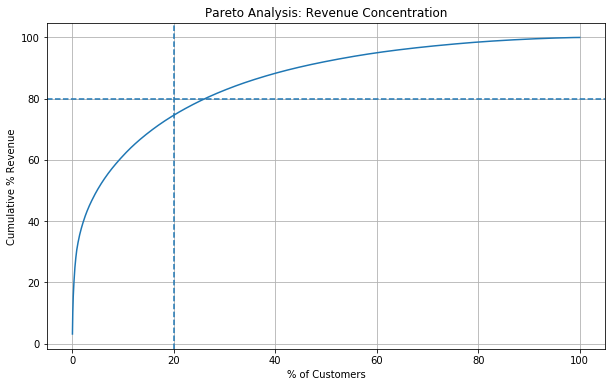

In [58]:
# Build Pareto Chart

# Build Pareto Chart

import matplotlib.pyplot as plt

x = pareto_df["Customer_Pct"].values
y = pareto_df["Cumulative_Revenue_Pct"].values

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(x, y)

ax.axhline(80, linestyle="--")
ax.axvline(20, linestyle="--")

ax.set_title("Pareto Analysis: Revenue Concentration")
ax.set_xlabel("% of Customers")
ax.set_ylabel("Cumulative % Revenue")

ax.grid(True)

fig.savefig(
    images_path / "pareto_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Calculate for Insights

customers_needed = (
    pareto_df[
        pareto_df["Cumulative_Revenue_Pct"] <= 80
    ]["Customer_Pct"]
    .max()
)

print(
    f"{round(customers_needed,1)}% of customers generate approximately 80% of revenue."
)

26.1% of customers generate approximately 80% of revenue.


Three segmentation approaches were evaluated:

1. Revenue Tiers (Low / Medium / High)
2. Pareto Analysis
3. RFM Segmentation

While revenue tiers provided a simple customer grouping and Pareto analysis highlighted revenue concentration, RFM segmentation was selected as the preferred framework because it incorporates customer value, purchase frequency, and recency simultaneously.

In [21]:
# Final Segmentation Method (RFM) Business Label Creation

rfm["Segment"] = "Regular"

rfm.loc[rfm["RFM_Score"] == "555", "Segment"] = "Champions"

rfm.loc[
    rfm["RFM_Score"].isin([
        "554","545","544",
        "455","445","355"
    ]),
    "Segment"
] = "Loyal High Value"

rfm.loc[
    rfm["RFM_Score"].isin([
        "111","112","121","122","211"
    ]),
    "Segment"
] = "At Risk"

rfm["Segment"].value_counts()

Regular             2842
At Risk              637
Loyal High Value     511
Champions            348
Name: Segment, dtype: int64

In [22]:
# Create revenue summary by RFM segment

segment_revenue = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "nunique"),
        Revenue=("Monetary", "sum")
    )
    .reset_index()
)

segment_revenue["Revenue_Pct"] = (
    segment_revenue["Revenue"] /
    segment_revenue["Revenue"].sum()
) * 100

segment_revenue

,Segment,Customers,Revenue,Revenue_Pct
0,At Risk,637,137380.720,1.541628
1,Champions,348,3905165.910,43.822098
2,Loyal High Value,511,2063184.180,23.152169
3,Regular,2842,2805677.094,31.484106


In [23]:
# Calculate Revenue by Customer by Segment

segment_revenue["Avg_Revenue_Per_Customer"] = (
    segment_revenue["Revenue"] /
    segment_revenue["Customers"]
)

segment_revenue.sort_values(
    "Revenue",
    ascending=False
)

,Segment,Customers,Revenue,Revenue_Pct,Avg_Revenue_Per_Customer
1,Champions,348,3905165.910,43.822098,11221.741121
3,Regular,2842,2805677.094,31.484106,987.219245
2,Loyal High Value,511,2063184.180,23.152169,4037.542427
0,At Risk,637,137380.720,1.541628,215.668320


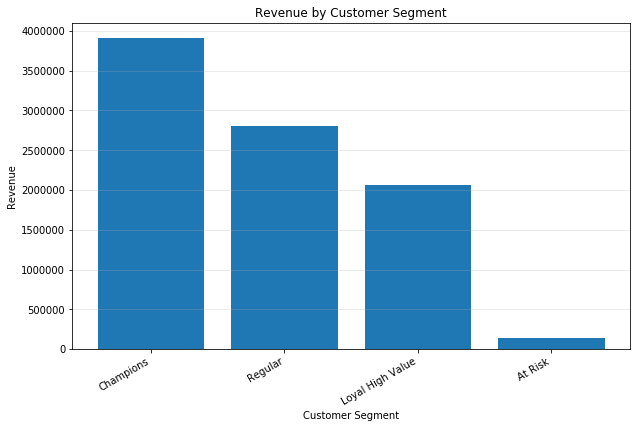

In [59]:
# Revenue by Customer Segment Chart

# Revenue by customer segment

segment_chart = segment_revenue.sort_values("Revenue", ascending=False)

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    segment_chart["Segment"],
    segment_chart["Revenue"]
)

ax.set_title("Revenue by Customer Segment")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Revenue")

plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)

fig.savefig(
    images_path / "revenue_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

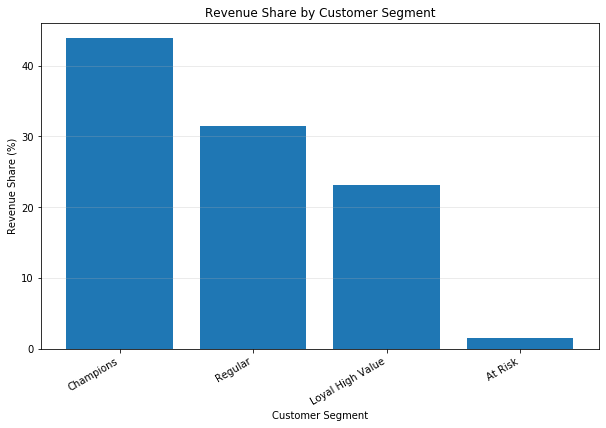

In [60]:
# Revenue share by customer segment chart

segment_share = segment_revenue.sort_values("Revenue_Pct", ascending=False)

fig, ax = plt.subplots(figsize=(10,6))

ax.bar(
    segment_share["Segment"],
    segment_share["Revenue_Pct"]
)

ax.set_title("Revenue Share by Customer Segment")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Revenue Share (%)")

plt.xticks(rotation=30, ha="right")
ax.grid(axis="y", alpha=0.3)

fig.savefig(
    images_path / "revenue_share_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## RFM Segmentation Insights

RFM analysis segmented customers into four meaningful groups based on purchasing recency, frequency, and monetary value.

### Key Findings

- **Champions** represent only 348 customers but generate approximately **44% of total revenue**.
- **Loyal High Value** customers contribute approximately **23% of revenue** and represent the strongest opportunity for upselling and cross-selling.
- **Regular** customers represent the largest customer segment and contribute approximately **31% of revenue**, indicating a large pool of customers that could be nurtured into higher-value segments.
- **At Risk** customers contribute less than **2% of revenue**, suggesting that retention efforts should focus primarily on higher-value segments.

### Business Implications

- Revenue is highly concentrated among a relatively small group of customers.
- Protecting and retaining Champion customers should be a strategic priority.
- Loyal High Value customers provide the greatest growth opportunity because they already demonstrate strong purchasing behavior.
- Marketing investments should prioritize high-value customer segments rather than broad, untargeted campaigns.
- RFM segmentation provides a practical framework for identifying customers who require retention, upsell, or re-engagement strategies.

### Revenue Contribution by Segment

| Segment | Revenue Contribution |
|----------|----------:|
| Champions | 43.8% |
| Loyal High Value | 23.2% |
| Regular | 31.5% |
| At Risk | 1.5% |

Overall, Champion and Loyal High Value customers account for approximately **67% of total revenue while representing only about 20% of customers**, reinforcing the importance of targeted customer relationship management.

# Step 6: Identify Growth Opportunities
Insights from Pareto Analysis, Revenue Segmentation, and RFM Segmentation were used to identify customer growth opportunities and revenue optimization strategies.

### Opportunity 1: Retain High-Value Customers

Pareto analysis showed that approximately 26% of customers generate 80% of total revenue.

These customers represent the most critical revenue source and should be prioritized through:

- Loyalty programs
- VIP customer support
- Personalized offers
- Early access to new products

Retaining a small number of high-value customers can have a significant impact on overall revenue performance.

### Opportunity 2: Upsell Loyal Customers

Loyal High Value customers contribute over 23% of total revenue and demonstrate strong purchasing behavior.

Potential actions include:

- Product recommendations
- Bundle offers
- Premium product promotions
- Cross-selling related products

These customers are the most likely group to increase spending with targeted marketing campaigns.

### Opportunity 3: Convert Regular Customers into High-Value Customers

Regular customers represent the largest customer segment.

Increasing purchase frequency or average order value among this group could significantly increase overall revenue.

Recommended strategies include:

- Email marketing campaigns
- Personalized recommendations
- Discount incentives
- Customer loyalty rewards

### Opportunity 4: Re-Engage At-Risk Customers

The At Risk segment contributes only a small percentage of total revenue but represents customers who may have previously engaged with the business.

Potential retention strategies include:

- Win-back campaigns
- Special discounts
- Reminder emails
- Product recommendations based on past purchases

These efforts may recover customers before they become inactive permanently.

In [24]:
opportunities = pd.DataFrame({
    "Opportunity": [
        "Protect High-Value Customers",
        "Upsell Loyal Customers",
        "Convert Regular Customers",
        "Re-Engage At-Risk Customers"
    ],
    "Expected Impact": [
        "Revenue Protection",
        "Revenue Growth",
        "Revenue Growth",
        "Customer Retention"
    ]
})

opportunities

,Opportunity,Expected Impact
0,Protect High-Value Customers,Revenue Protection
1,Upsell Loyal Customers,Revenue Growth
2,Convert Regular Customers,Revenue Growth
3,Re-Engage At-Risk Customers,Customer Retention


# Step 7: Revenue Growth Simulation

Three revenue simulations were modeled to estimate the business impact of targeted customer growth and retention strategies:

1. **Segment Migration:** Estimate revenue gain if a percentage of customers move from a lower-value segment to a higher-value segment.
2. **Champion Churn Reduction:** Estimate revenue protected by preventing churn among Champion customers.
3. **Purchase Frequency Lift:** Estimate incremental revenue if a percentage of Regular customers place one additional order.

These simulations avoid applying a generic flat revenue increase and instead connect revenue impact to specific customer behaviors and business actions.

### Scenario 1: Segment Migration Simulation

Assume:

10% of Regular customers become Loyal High Value
10% of At Risk customers become Regular

In [25]:
# Scenario 1: 10% Upgrades from Regular to Loyal and 10% At Risk to Regular

regular_customers = 2842
at_risk_customers = 637

regular_avg = 987.22
loyal_avg = 4037.54
at_risk_avg = 215.67

# Migration assumptions

regular_to_loyal = regular_customers * 0.10
atrisk_to_regular = at_risk_customers * 0.10

# Revenue gain

gain_regular = regular_to_loyal * (loyal_avg - regular_avg)

gain_atrisk = atrisk_to_regular * (regular_avg - at_risk_avg)

total_gain = gain_regular + gain_atrisk

print("Estimated Revenue Increase: $", round(total_gain,2))

Estimated Revenue Increase: $ 916048.68


Business Interpretation

If only 10% of customers move up one segment:

Regular → Loyal High Value
At Risk → Regular

The company could generate approximately $900K+ in additional revenue.

### Scenario 2: Reduce Champion Churn

What revenue is protected if we retain Champions who would otherwise leave?

In [26]:
# Scenario 2: Reduce Champion Churn

champion_data = segment_revenue[
    segment_revenue["Segment"] == "Champions"
].iloc[0]

champion_revenue = champion_data["Revenue"]

churn_scenarios = [0.05, 0.10, 0.15]

churn_impact = []

for churn_rate in churn_scenarios:
    revenue_at_risk = champion_revenue * churn_rate
    
    churn_impact.append({
        "Scenario": f"Prevent {int(churn_rate * 100)}% Champion Churn",
        "Revenue Protected": round(revenue_at_risk, 2)
    })

churn_impact_df = pd.DataFrame(churn_impact)

churn_impact_df

,Scenario,Revenue Protected
0,Prevent 5% Champion Churn,195258.30
1,Prevent 10% Champion Churn,390516.59
2,Prevent 15% Champion Churn,585774.89


### Scenario 3: Increase Purchase Frequency of Regular Customers

This assumes a share of Regular customers place one additional order at the current Regular segment average order value.

In [27]:
# Scenario 3: Increase Purchase Frequency Among Regular Customers

regular_customers = rfm[
    rfm["Segment"] == "Regular"
]["CustomerID"].nunique()

regular_transactions = clean_df[
    clean_df["CustomerID"].isin(
        rfm[rfm["Segment"] == "Regular"]["CustomerID"]
    )
]

regular_avg_order_value = (
    regular_transactions["Revenue"].sum() /
    regular_transactions["InvoiceNo"].nunique()
)

frequency_scenarios = [0.05, 0.10, 0.15]

frequency_impact = []

for conversion_rate in frequency_scenarios:
    customers_with_extra_order = regular_customers * conversion_rate
    estimated_revenue_gain = customers_with_extra_order * regular_avg_order_value
    
    frequency_impact.append({
        "Scenario": f"{int(conversion_rate * 100)}% of Regular Customers Place 1 Extra Order",
        "Customers Impacted": round(customers_with_extra_order),
        "Estimated Revenue Gain": round(estimated_revenue_gain, 2)
    })

frequency_impact_df = pd.DataFrame(frequency_impact)

frequency_impact_df

,Scenario,Customers Impacted,Estimated Revenue Gain
0,5% of Regular Customers Place 1 Extra Order,142,53479.10
1,10% of Regular Customers Place 1 Extra Order,284,106958.21
2,15% of Regular Customers Place 1 Extra Order,426,160437.31


# Step 8: Product Affinity Analysis

Having identified the customer segments that drive growth, the next step is understanding which products are most strongly associated with high-value customer behavior.

In [28]:
# Create Transaction Dataset with Segments
segment_transactions = clean_df.merge(
    rfm[["CustomerID", "Segment"]],
    on="CustomerID",
    how="left"
)

segment_transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,Regular
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Regular
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,Regular
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Regular
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,Regular


In [29]:
# Top Products Purchased by Champions
champion_products = (
    segment_transactions[
        segment_transactions["Segment"] == "Champions"
    ]
    .groupby("Description")
    .agg({
        "Revenue":"sum"
    })
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(20)
)

champion_products

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,79686.30
WHITE HANGING HEART T-LIGHT HOLDER,49332.75
JUMBO BAG RED RETROSPOT,45451.57
BLACK RECORD COVER FRAME,29629.49
PARTY BUNTING,27411.13
WOOD BLACK BOARD ANT WHITE FINISH,25417.46
RABBIT NIGHT LIGHT,24711.87
CHILLI LIGHTS,22521.70
DOORMAT KEEP CALM AND COME IN,22173.04


In [30]:
# Top Products Purchased by Regular Customer
regular_products = (
    segment_transactions[
        segment_transactions["Segment"] == "Regular"
    ]
    .groupby("Description")
    .agg({
        "Revenue":"sum"
    })
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(20)
)

regular_products

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
MEDIUM CERAMIC TOP STORAGE JAR,78326.87
PICNIC BASKET WICKER 60 PIECES,39619.50
WHITE HANGING HEART T-LIGHT HOLDER,32501.15
REGENCY CAKESTAND 3 TIER,29469.85
POSTAGE,25863.24
PARTY BUNTING,23008.10
Manual,19255.62
JUMBO BAG RED RETROSPOT,18670.35


In [31]:
# Product Summary Table
product_summary = (
    segment_transactions
    .groupby("Description")
    .agg(
        Revenue=("Revenue","sum"),
        Customers=("CustomerID","nunique"),
        Orders=("InvoiceNo","nunique"),
        Units_Sold=("Quantity","sum"),
        Avg_Unit_Price=("UnitPrice","mean")
    )
    .reset_index()
)

product_summary["Revenue_Per_Customer"] = (
    product_summary["Revenue"] /
    product_summary["Customers"]
)

product_summary.sort_values(
    "Revenue",
    ascending=False
).head(25)

,Description,Revenue,Customers,Orders,Units_Sold,Avg_Unit_Price,Revenue_Per_Customer
2319,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1,1,80995,2.080000,168469.600000
2767,REGENCY CAKESTAND 3 TIER,142592.95,881,1703,12402,12.483401,161.853519
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,856,1971,36725,2.893107,117.345970
1762,JUMBO BAG RED RETROSPOT,85220.78,635,1600,46181,2.015878,134.205953
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,138,195,77916,1.220303,589.976304
2611,POSTAGE,77803.96,331,1099,3120,31.570482,235.057281
2345,PARTY BUNTING,68844.33,708,1379,15291,4.876375,97.237754
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,678,1375,35362,1.680795,83.451829
2130,Manual,53779.93,197,253,7173,175.291585,272.994569
2656,RABBIT NIGHT LIGHT,51346.20,450,801,27202,2.013943,114.102667


In [32]:
clean_df[
    clean_df["Description"] == "PAPER CRAFT , LITTLE BIRDIE"
][[
    "CustomerID",
    "InvoiceNo",
    "Quantity",
    "UnitPrice",
    "Revenue"
]].sort_values(
    "Revenue",
    ascending=False
).head(20)

,CustomerID,InvoiceNo,Quantity,UnitPrice,Revenue
540421,16446.0,581483,80995,2.08,168469.6


In [33]:
clean_df[
    clean_df["Description"] == "PICNIC BASKET WICKER 60 PIECES"
][[
    "CustomerID",
    "InvoiceNo",
    "Quantity",
    "UnitPrice",
    "Revenue"
]].sort_values(
    "Revenue",
    ascending=False
).head(20)

,CustomerID,InvoiceNo,Quantity,UnitPrice,Revenue
222680,15098.0,556444,60,649.5,38970.0
222682,15098.0,556446,1,649.5,649.5


### Product-Level Outlier Validation

A small number of products generated very high revenue from a limited number of customers. These transactions were reviewed and appear to be legitimate bulk purchases or high-value orders rather than data errors.

These products were retained in the revenue analysis because they represent real customer spending patterns.

However, products purchased by only a few customers offer limited cross-sell potential. Therefore, growth opportunity recommendations focus on products with both strong revenue performance and broader customer adoption.

Products with customer penetration below 0.1% were excluded from growth recommendation analysis.

In [34]:
# Step 8: View 1 Product Performance (Includes Outliers)

# Total customers overall
total_customers = rfm["CustomerID"].nunique()

# Segment sizes
segment_sizes = (
    rfm.groupby("Segment")["CustomerID"]
    .nunique()
)

# Product-level summary
product_summary = (
    segment_transactions
    .groupby("Description")
    .agg(
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique"),
        Units_Sold=("Quantity", "sum"),
        Avg_Unit_Price=("UnitPrice", "mean")
    )
    .reset_index()
)

# Revenue contribution %
product_summary["Revenue_Pct"] = (
    product_summary["Revenue"] /
    product_summary["Revenue"].sum()
) * 100

# Overall product penetration
product_summary["Overall_Penetration_Pct"] = (
    product_summary["Customers"] / total_customers
) * 100

product_summary["Revenue_Per_Customer"] = (
    product_summary["Revenue"] / product_summary["Customers"]
)

# Segment-level product penetration
product_segment = (
    segment_transactions
    .groupby(["Description", "Segment"])
    .agg(
        Segment_Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

product_segment["Segment_Size"] = product_segment["Segment"].map(segment_sizes)

product_segment["Segment_Penetration_Pct"] = (
    product_segment["Segment_Customers"] /
    product_segment["Segment_Size"]
) * 100

# Pivot segment penetration into columns
segment_penetration = (
    product_segment
    .pivot_table(
        index="Description",
        columns="Segment",
        values="Segment_Penetration_Pct",
        fill_value=0
    )
    .reset_index()
)

segment_penetration.columns.name = None

# Combine product summary + segment penetration
product_affinity_overview = product_summary.merge(
    segment_penetration,
    on="Description",
    how="left"
)

# Round numbers for readability
product_affinity_overview = product_affinity_overview.round({
    "Revenue": 2,
    "Revenue_Pct": 2,
    "Avg_Unit_Price": 2,
    "Revenue_Per_Customer": 2,
    "Overall_Penetration_Pct": 2,
    "Champions": 2,
    "Loyal High Value": 2,
    "Regular": 2,
    "At Risk": 2
})

# Final table: top products by revenue, with segment penetration
product_affinity_overview.sort_values(
    "Revenue",
    ascending=False
).head(25)

,Description,Revenue,Customers,Orders,Units_Sold,Avg_Unit_Price,Revenue_Pct,Overall_Penetration_Pct,Revenue_Per_Customer,At Risk,Champions,Loyal High Value,Regular
2319,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1,1,80995,2.08,1.89,0.02,168469.60,0.00,0.00,0.00,0.04
2767,REGENCY CAKESTAND 3 TIER,142592.95,881,1703,12402,12.48,1.60,20.31,161.85,9.58,39.66,34.64,17.77
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,856,1971,36725,2.89,1.13,19.73,117.35,12.87,40.80,29.35,16.96
1762,JUMBO BAG RED RETROSPOT,85220.78,635,1600,46181,2.02,0.96,14.64,134.21,5.02,42.24,30.33,10.59
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,138,195,77916,1.22,0.91,3.18,589.98,0.47,10.63,4.89,2.57
2611,POSTAGE,77803.96,331,1099,3120,31.57,0.87,7.63,235.06,5.49,9.77,12.92,6.90
2345,PARTY BUNTING,68844.33,708,1379,15291,4.88,0.77,16.32,97.24,8.16,38.22,27.79,13.41
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,678,1375,35362,1.68,0.63,15.63,83.45,6.44,31.61,25.83,13.90
2130,Manual,53779.93,197,253,7173,175.29,0.60,4.54,272.99,0.78,11.78,8.61,3.76
2656,RABBIT NIGHT LIGHT,51346.20,450,801,27202,2.01,0.58,10.37,114.10,0.47,31.03,23.68,7.67


In [35]:
# View 2: Product Overview (Excludes niche products)

growth_products = product_affinity_overview[
    product_affinity_overview["Customers"] >= 10
].copy()

growth_products["Growth_Score"] = (
    growth_products["Revenue_Pct"] *
    growth_products["Overall_Penetration_Pct"]
)

growth_products[
    [
        "Description",
        "Revenue",
        "Revenue_Pct",
        "Customers",
        "Overall_Penetration_Pct",
        "Revenue_Per_Customer",
        "Champions",
        "Loyal High Value",
        "Regular",
        "At Risk"
    ]
].sort_values(
    "Revenue",
    ascending=False
).head(20)

,Description,Revenue,Revenue_Pct,Customers,Overall_Penetration_Pct,Revenue_Per_Customer,Champions,Loyal High Value,Regular,At Risk
2767,REGENCY CAKESTAND 3 TIER,142592.95,1.60,881,20.31,161.85,39.66,34.64,17.77,9.58
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,1.13,856,19.73,117.35,40.80,29.35,16.96,12.87
1762,JUMBO BAG RED RETROSPOT,85220.78,0.96,635,14.64,134.21,42.24,30.33,10.59,5.02
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,0.91,138,3.18,589.98,10.63,4.89,2.57,0.47
2611,POSTAGE,77803.96,0.87,331,7.63,235.06,9.77,12.92,6.90,5.49
2345,PARTY BUNTING,68844.33,0.77,708,16.32,97.24,38.22,27.79,13.41,8.16
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,0.63,678,15.63,83.45,31.61,25.83,13.90,6.44
2130,Manual,53779.93,0.60,197,4.54,272.99,11.78,8.61,3.76,0.78
2656,RABBIT NIGHT LIGHT,51346.20,0.58,450,10.37,114.10,31.03,23.68,7.67,0.47
722,CHILLI LIGHTS,46286.51,0.52,205,4.73,225.79,16.38,8.61,3.38,1.26


In [36]:
# View 3: Product Opportunity Index

growth_products["Growth_Score"] = (
    growth_products["Revenue_Pct"] *
    growth_products["Overall_Penetration_Pct"] *
    growth_products["Champions"]
)

growth_products[
    [
        "Description",
        "Revenue",
        "Revenue_Pct",
        "Customers",
        "Overall_Penetration_Pct",
        "Champions",
        "Growth_Score"
    ]
].sort_values(
    "Growth_Score",
    ascending=False
).head(20)

,Description,Revenue,Revenue_Pct,Customers,Overall_Penetration_Pct,Champions,Growth_Score
2767,REGENCY CAKESTAND 3 TIER,142592.95,1.60,881,20.31,39.66,1288.791360
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,1.13,856,19.73,40.80,909.631920
1762,JUMBO BAG RED RETROSPOT,85220.78,0.96,635,14.64,42.24,593.657856
2345,PARTY BUNTING,68844.33,0.77,708,16.32,38.22,480.287808
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,0.63,678,15.63,31.61,311.260509
2313,PAPER CHAIN KIT 50'S CHRISTMAS,42660.83,0.48,613,14.13,32.18,218.257632
3001,SET OF 3 CAKE TINS PANTRY DESIGN,33347.80,0.37,640,14.75,34.48,188.174600
2656,RABBIT NIGHT LIGHT,51346.20,0.58,450,10.37,31.03,186.633038
3324,SPOTTY BUNTING,35539.25,0.40,571,13.16,35.34,186.029760
1943,LUNCH BAG RED RETROSPOT,28048.45,0.31,532,12.26,38.79,147.425274


## Product Opportunity Index

### Option 1: Growth Index

Measures products that already drive revenue and are strongly associated with high-value customers

- Generate high revenue
- Are purchased by many customers
- Are popular among Champions

In [37]:
product_affinity_overview["Growth_Index"] = (
    product_affinity_overview["Revenue_Pct"] *
    product_affinity_overview["Overall_Penetration_Pct"] *
    product_affinity_overview["Champions"]
)

product_affinity_overview.sort_values(
    "Growth_Index",
    ascending=False
).head(20)

,Description,Revenue,Customers,Orders,Units_Sold,Avg_Unit_Price,Revenue_Pct,Overall_Penetration_Pct,Revenue_Per_Customer,At Risk,Champions,Loyal High Value,Regular,Growth_Index
2767,REGENCY CAKESTAND 3 TIER,142592.95,881,1703,12402,12.48,1.60,20.31,161.85,9.58,39.66,34.64,17.77,1288.791360
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,856,1971,36725,2.89,1.13,19.73,117.35,12.87,40.80,29.35,16.96,909.631920
1762,JUMBO BAG RED RETROSPOT,85220.78,635,1600,46181,2.02,0.96,14.64,134.21,5.02,42.24,30.33,10.59,593.657856
2345,PARTY BUNTING,68844.33,708,1379,15291,4.88,0.77,16.32,97.24,8.16,38.22,27.79,13.41,480.287808
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,678,1375,35362,1.68,0.63,15.63,83.45,6.44,31.61,25.83,13.90,311.260509
2313,PAPER CHAIN KIT 50'S CHRISTMAS,42660.83,613,980,15617,2.94,0.48,14.13,69.59,2.67,32.18,27.59,12.07,218.257632
3001,SET OF 3 CAKE TINS PANTRY DESIGN,33347.80,640,1146,7020,4.95,0.37,14.75,52.11,4.40,34.48,27.79,12.32,188.174600
2656,RABBIT NIGHT LIGHT,51346.20,450,801,27202,2.01,0.58,10.37,114.10,0.47,31.03,23.68,7.67,186.633038
3324,SPOTTY BUNTING,35539.25,571,1003,7639,4.92,0.40,13.16,62.24,1.26,35.34,24.07,11.15,186.029760
1943,LUNCH BAG RED RETROSPOT,28048.45,532,1288,17697,1.66,0.31,12.26,52.72,2.51,38.79,28.18,8.34,147.425274


### Option 2: Expansion Index
Find products that Champions buy but Regular customers do not.

In [38]:
product_affinity_overview["Expansion_Index"] = (
    product_affinity_overview["Champions"] -
    product_affinity_overview["Regular"]
)

product_affinity_overview.sort_values(
    "Expansion_Index",
    ascending=False
).head(20)

,Description,Revenue,Customers,Orders,Units_Sold,Avg_Unit_Price,Revenue_Pct,Overall_Penetration_Pct,Revenue_Per_Customer,At Risk,Champions,Loyal High Value,Regular,Growth_Index,Expansion_Index
1762,JUMBO BAG RED RETROSPOT,85220.78,635,1600,46181,2.02,0.96,14.64,134.21,5.02,42.24,30.33,10.59,593.657856,31.65
1943,LUNCH BAG RED RETROSPOT,28048.45,532,1288,17697,1.66,0.31,12.26,52.72,2.51,38.79,28.18,8.34,147.425274,30.45
2269,PACK OF 72 RETROSPOT CAKE CASES,16394.53,635,1029,33693,0.55,0.18,14.64,25.82,3.45,41.09,28.18,11.47,108.280368,29.62
2345,PARTY BUNTING,68844.33,708,1379,15291,4.88,0.77,16.32,97.24,8.16,38.22,27.79,13.41,480.287808,24.81
3324,SPOTTY BUNTING,35539.25,571,1003,7639,4.92,0.40,13.16,62.24,1.26,35.34,24.07,11.15,186.029760,24.19
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,856,1971,36725,2.89,1.13,19.73,117.35,12.87,40.80,29.35,16.96,909.631920,23.84
3012,SET OF 3 REGENCY CAKE TINS,26625.68,472,718,5856,4.93,0.30,10.88,56.41,0.31,32.47,19.96,8.97,105.982080,23.50
3050,SET OF 4 PANTRY JELLY MOULDS,14180.17,431,866,11792,1.26,0.16,9.94,32.90,2.20,30.75,20.35,7.25,48.904800,23.50
1935,LUNCH BAG BLACK SKULL.,18024.55,458,1052,11291,1.64,0.20,10.56,39.35,2.51,30.75,24.66,7.35,64.944000,23.40
3106,SET/20 RED RETROSPOT PAPER NAPKINS,9656.79,427,732,12313,0.84,0.11,9.84,22.62,3.14,30.75,17.61,7.39,33.283800,23.36


### Option 3: Bundle Index
Identify products with:

- High penetration
- High repeat orders

In [39]:
product_affinity_overview["Bundle_Index"] = (
    product_affinity_overview["Orders"] *
    product_affinity_overview["Overall_Penetration_Pct"]
)

product_affinity_overview.sort_values(
    "Bundle_Index",
    ascending=False
).head(20)

,Description,Revenue,Customers,Orders,Units_Sold,Avg_Unit_Price,Revenue_Pct,Overall_Penetration_Pct,Revenue_Per_Customer,At Risk,Champions,Loyal High Value,Regular,Growth_Index,Expansion_Index,Bundle_Index
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,856,1971,36725,2.89,1.13,19.73,117.35,12.87,40.80,29.35,16.96,909.631920,23.84,38887.83
2767,REGENCY CAKESTAND 3 TIER,142592.95,881,1703,12402,12.48,1.60,20.31,161.85,9.58,39.66,34.64,17.77,1288.791360,21.89,34587.93
1762,JUMBO BAG RED RETROSPOT,85220.78,635,1600,46181,2.02,0.96,14.64,134.21,5.02,42.24,30.33,10.59,593.657856,31.65,23424.00
2345,PARTY BUNTING,68844.33,708,1379,15291,4.88,0.77,16.32,97.24,8.16,38.22,27.79,13.41,480.287808,24.81,22505.28
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,678,1375,35362,1.68,0.63,15.63,83.45,6.44,31.61,25.83,13.90,311.260509,17.71,21491.25
3001,SET OF 3 CAKE TINS PANTRY DESIGN,33347.80,640,1146,7020,4.95,0.37,14.75,52.11,4.40,34.48,27.79,12.32,188.174600,22.16,16903.50
1943,LUNCH BAG RED RETROSPOT,28048.45,532,1288,17697,1.66,0.31,12.26,52.72,2.51,38.79,28.18,8.34,147.425274,30.45,15790.88
2269,PACK OF 72 RETROSPOT CAKE CASES,16394.53,635,1029,33693,0.55,0.18,14.64,25.82,3.45,41.09,28.18,11.47,108.280368,29.62,15064.56
2313,PAPER CHAIN KIT 50'S CHRISTMAS,42660.83,613,980,15617,2.94,0.48,14.13,69.59,2.67,32.18,27.59,12.07,218.257632,20.11,13847.40
3324,SPOTTY BUNTING,35539.25,571,1003,7639,4.92,0.40,13.16,62.24,1.26,35.34,24.07,11.15,186.029760,24.19,13199.48


### Option 4: Build Transaction Baskets
Offer bundled promotions for frequently co-purchased products.

In [40]:
# create basket
basket = (
    clean_df
    .groupby("InvoiceNo")["Description"]
    .apply(list)
)

In [41]:
# Simple Product Pair Analysis
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for products in basket:
    
    products = list(set(products))
    
    for pair in combinations(products, 2):
        pair_counter[tuple(sorted(pair))] += 1

top_pairs = (
    pd.DataFrame(
        pair_counter.items(),
        columns=["Pair","Frequency"]
    )
)

top_pairs.sort_values(
    "Frequency",
    ascending=False
).head(20)

,Pair,Frequency
11860,"(JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROS...",546
31470,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",541
223,"(ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKEL...",530
3569,"(LUNCH BAG PINK POLKADOT, LUNCH BAG RED RETROS...",523
7087,"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROS...",517
326,"(WOODEN FRAME ANTIQUE WHITE , WOODEN PICTURE F...",468
2503,"(LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY D...",467
40135,"(LUNCH BAG BLACK SKULL., LUNCH BAG PINK POLKA...",464
986208,"(GARDENERS KNEELING PAD CUP OF TEA , GARDENERS...",463
172433,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",460


In [42]:
# Advanced Version (Apriori) Note: this is without mixtrends which didn't support in current python version.

from itertools import combinations
from collections import Counter

# Build product baskets at invoice level
basket = clean_df.groupby("InvoiceNo")["Description"].apply(list)

# Count product pairs purchased together
pair_counter = Counter()

for products in basket:
    unique_products = sorted(set(products))
    
    for pair in combinations(unique_products, 2):
        pair_counter[pair] += 1

# Convert to dataframe
pair_df = pd.DataFrame(
    pair_counter.items(),
    columns=["Product_Pair", "Times_Purchased_Together"]
)

# Split pair into Product A and Product B
pair_df["Product_A"] = pair_df["Product_Pair"].apply(lambda x: x[0])
pair_df["Product_B"] = pair_df["Product_Pair"].apply(lambda x: x[1])

# Final table
top_product_pairs = pair_df[
    ["Product_A", "Product_B", "Times_Purchased_Together"]
].sort_values(
    "Times_Purchased_Together",
    ascending=False
)

top_product_pairs.head(20)

,Product_A,Product_B,Times_Purchased_Together
12420,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546
31474,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,541
114,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,530
3475,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,523
7948,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,517
382,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,468
3510,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,467
40900,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,464
986208,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,463
172121,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,460


In [43]:
# Product revenue by invoice

invoice_products = (
    clean_df.groupby(
        ["InvoiceNo", "Description"]
    )["Revenue"]
    .sum()
    .reset_index()
)

In [44]:
# Build Product Pairs + Bundle Revenue
from itertools import combinations
from collections import Counter
import pandas as pd

pair_counter = Counter()
pair_revenue = Counter()

for invoice, group in invoice_products.groupby("InvoiceNo"):

    products = group["Description"].tolist()

    revenue_map = dict(
        zip(
            group["Description"],
            group["Revenue"]
        )
    )

    for pair in combinations(sorted(products), 2):

        pair_counter[pair] += 1

        bundle_rev = (
            revenue_map[pair[0]]
            + revenue_map[pair[1]]
        )

        pair_revenue[pair] += bundle_rev


In [45]:
# final table market basket with revenue and count

bundle_analysis = pd.DataFrame(
    [
        [
            pair[0],
            pair[1],
            pair_counter[pair],
            pair_revenue[pair]
        ]
        for pair in pair_counter.keys()
    ],
    columns=[
        "Product_A",
        "Product_B",
        "Times_Purchased_Together",
        "Bundle_Revenue"
    ]
)

In [46]:
# Average Revenue per Bundle Purchase
bundle_analysis["Avg_Revenue_Per_Bundle"] = (
    bundle_analysis["Bundle_Revenue"]
    /
    bundle_analysis["Times_Purchased_Together"]
)

In [47]:
# Top Revenue Generating Bundles
bundle_analysis.sort_values(
    "Bundle_Revenue",
    ascending=False
).head(20)

,Product_A,Product_B,Times_Purchased_Together,Bundle_Revenue,Avg_Revenue_Per_Bundle
12420,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546,55123.22,100.958278
6484,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,414,54391.81,131.381184
18452,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,420,52023.68,123.865905
28667,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,455,43968.72,96.634549
31473,GREEN REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,374,40116.96,107.264599
1249,HEART OF WICKER LARGE,HEART OF WICKER SMALL,407,35255.27,86.622285
172370,PINK REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,309,34601.23,111.978091
863161,JUMBO BAG APPLES,JUMBO BAG RED RETROSPOT,351,34544.73,98.418034
22300,JUMBO BAG PINK POLKADOT,JUMBO BAG STRAWBERRY,293,34535.86,117.869829
4106,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,451,33137.08,73.474678


In [48]:
# Create a Bundle Opportunity Score:
bundle_analysis["Bundle_Opportunity_Score"] = (
    bundle_analysis["Times_Purchased_Together"]
    *
    bundle_analysis["Avg_Revenue_Per_Bundle"]
)

In [49]:
# sort by bundle opportunity score
bundle_analysis.sort_values(
    "Bundle_Opportunity_Score",
    ascending=False
).head(20)

,Product_A,Product_B,Times_Purchased_Together,Bundle_Revenue,Avg_Revenue_Per_Bundle,Bundle_Opportunity_Score
12420,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,546,55123.22,100.958278,55123.22
6484,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,414,54391.81,131.381184,54391.81
18452,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,420,52023.68,123.865905,52023.68
28667,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,455,43968.72,96.634549,43968.72
31473,GREEN REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,374,40116.96,107.264599,40116.96
1249,HEART OF WICKER LARGE,HEART OF WICKER SMALL,407,35255.27,86.622285,35255.27
172370,PINK REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,309,34601.23,111.978091,34601.23
863161,JUMBO BAG APPLES,JUMBO BAG RED RETROSPOT,351,34544.73,98.418034,34544.73
22300,JUMBO BAG PINK POLKADOT,JUMBO BAG STRAWBERRY,293,34535.86,117.869829,34535.86
4106,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,451,33137.08,73.474678,33137.08


## Market Basket Analysis Insights

Market Basket Analysis identified several product combinations that customers consistently purchase together. The strongest co-purchase patterns were observed within product families such as Jumbo Bags, Regency collections, Home Decor products, and Lunch Bags, indicating that customers often buy coordinated collections rather than individual products.

The highest-performing bundle was **JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT**, purchased together **546 times** and generating over **£55K** in bundle revenue. Similar patterns were observed across other Jumbo Bag variants, suggesting strong opportunities for bundle offers and multi-buy promotions.

The **Regency collection** also showed significant cross-sell potential. Products such as **REGENCY CAKESTAND 3 TIER** and various Regency Teacup designs were frequently purchased together, generating more than **£50K** in bundle revenue. This indicates that customers view these products as part of a coordinated collection and are receptive to collection-based recommendations.

Home Decor products such as **HEART OF WICKER** and **WHITE HANGING HEART T-LIGHT HOLDER** were commonly purchased together, while Lunch Bags and Lunch Boxes demonstrated similar purchasing patterns. These combinations present opportunities for curated bundles and targeted cross-sell recommendations.

### Business Recommendations

- Create bundle offers around high-frequency product families such as Jumbo Bags, Regency collections, and Home Decor products.
- Implement recommendation engines that suggest complementary products based on historical co-purchase behavior.
- Promote coordinated product collections rather than individual products.
- Use checkout and email recommendations to increase average order value and cross-sell revenue.

### Key Takeaway

Customers demonstrate strong collection-based purchasing behavior. Product bundling and AI-driven recommendations represent a significant opportunity to increase basket size, improve cross-sell performance, and drive incremental revenue growth.

## Next Best Product Recommendation Table
"If a customer buys Product A, what should we recommend next?

In [50]:
# Rank recommendations by frequency

recommendations = bundle_analysis.copy()

recommendations["Rank"] = (
    recommendations
    .groupby("Product_A")["Times_Purchased_Together"]
    .rank(method="first", ascending=False)
)

top3 = recommendations[
    recommendations["Rank"] <= 3
]

In [51]:
# Create 3-product recommendation bundle table

recommendation_bundle = (
    top3
    .groupby("Product_A")
    .agg(
        Recommendation_1=("Product_B", lambda x: list(x)[0] if len(x) > 0 else None),
        Recommendation_2=("Product_B", lambda x: list(x)[1] if len(x) > 1 else None),
        Recommendation_3=("Product_B", lambda x: list(x)[2] if len(x) > 2 else None),

        Total_CoPurchase_Count=("Times_Purchased_Together", "sum"),
        Total_Incremental_Revenue_Potential=("Bundle_Revenue", "sum")
    )
    .reset_index()
)

# Optional: remove low-signal product groups
recommendation_bundle = recommendation_bundle[
    recommendation_bundle["Total_CoPurchase_Count"] >= 50
]

# Sort by highest revenue opportunity
recommendation_bundle = recommendation_bundle.sort_values(
    "Total_Incremental_Revenue_Potential",
    ascending=False
)

recommendation_bundle.head(20)

,Product_A,Recommendation_1,Recommendation_2,Recommendation_3,Total_CoPurchase_Count,Total_Incremental_Revenue_Potential
1759,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,JUMBO STORAGE BAG SUKI,LUNCH BAG RED RETROSPOT,1273,113244.83
1757,JUMBO BAG PINK POLKADOT,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,1120,108430.27
2761,REGENCY CAKESTAND 3 TIER,WHITE HANGING HEART T-LIGHT HOLDER,ROSES REGENCY TEACUP AND SAUCER,SET OF 3 REGENCY CAKE TINS,904,100101.43
1507,GREEN REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,1375,95730.52
2521,PINK REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,REGENCY TEAPOT ROSES,876,76109.75
2340,PARTY BUNTING,REGENCY CAKESTAND 3 TIER,WHITE HANGING HEART T-LIGHT HOLDER,SPOTTY BUNTING,897,75393.39
1606,HEART OF WICKER LARGE,HEART OF WICKER SMALL,WHITE HANGING HEART T-LIGHT HOLDER,LARGE WHITE HEART OF WICKER,889,73117.30
1750,JUMBO BAG APPLES,LUNCH BAG APPLE DESIGN,JUMBO BAG RED RETROSPOT,JUMBO BAG PEARS,959,67196.46
2605,POSTAGE,ROUND SNACK BOXES SET OF4 WOODLAND,REGENCY CAKESTAND 3 TIER,ROUND SNACK BOXES SET OF 4 FRUITS,545,66304.95
1747,JUMBO BAG BAROQUE BLACK WHITE,JUMBO BAG PINK POLKADOT,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,853,64771.80


# Step 9: AI-Powered Recommendation Strategy

The final step converts customer segmentation, product affinity, and market basket analysis into actionable recommendation logic.

This framework can support:
- next-best-product recommendations
- product bundles
- cross-sell campaigns
- personalized marketing by customer segment

In [52]:
# Recommendation Logic Table

recommendation_strategy = pd.DataFrame({
    "Customer Segment": [
        "Champions",
        "Loyal High Value",
        "Regular",
        "At Risk"
    ],
    "Recommended Strategy": [
        "Retain with VIP offers and early access to high-value bundles",
        "Upsell into Champion behavior using premium product recommendations",
        "Increase purchase frequency through bundle offers and cross-sell recommendations",
        "Use low-cost win-back campaigns and targeted discounts"
    ],
    "Product Recommendation Logic": [
        "Recommend premium collections and complementary products",
        "Recommend products frequently purchased by Champions",
        "Recommend top 3 products from market basket analysis",
        "Recommend lower-cost popular products with broad adoption"
    ]
})

recommendation_strategy

,Customer Segment,Recommended Strategy,Product Recommendation Logic
0,Champions,Retain with VIP offers and early access to hig...,Recommend premium collections and complementar...
1,Loyal High Value,Upsell into Champion behavior using premium pr...,Recommend products frequently purchased by Cha...
2,Regular,Increase purchase frequency through bundle off...,Recommend top 3 products from market basket an...
3,At Risk,Use low-cost win-back campaigns and targeted d...,Recommend lower-cost popular products with bro...


# Step 10: Executive Recommendations

## Key Findings
- Champions are the most valuable customer segment. Although they represent only 348 customers, they generated approximately 44% of total revenue and spent an average of £11,222 per customer, far exceeding all other segments.
- Regular customers represent the largest growth opportunity. With 2,842 customers and over 31% of total revenue, even small improvements in purchase frequency could create significant revenue growth due to the size of this segment.
- Loyal High Value customers are the best candidates for migration into Champions. These customers already contribute over 23% of total revenue and spend more than £4,000 per customer on average, indicating strong potential for further growth.
- Product revenue is concentrated around a few highly adopted products. Items such as REGENCY CAKESTAND 3 TIER, WHITE HANGING HEART T-LIGHT HOLDER, and JUMBO BAG RED RETROSPOT generated high revenue while also being purchased by hundreds of customers.
- Customers frequently purchase products within the same collection. For example, JUMBO BAG PINK POLKADOT and JUMBO BAG RED RETROSPOT were purchased together 546 times, generating over £55,000 in bundle revenue.
- Regency products show exceptionally strong affinity patterns. Customers purchasing REGENCY CAKESTAND 3 TIER frequently also purchased ROSES REGENCY TEACUP AND SAUCER, generating over £52,000 in bundle revenue and highlighting a natural cross-sell opportunity.

## Business Recommendations
- Focus retention efforts on Champions, as losing a small number of these customers would have a disproportionate impact on revenue.
- Target Regular customers with bundle offers and personalized recommendations to increase purchase frequency and move them into higher-value segments.
- Use high-performing product families such as Regency collections, Jumbo Bags, and Home Décor products for cross-sell campaigns and bundled promotions.
- Implement a Next Best Product recommendation engine that recommends products frequently purchased together, such as suggesting JUMBO BAG STRAWBERRY or JUMBO BAG APPLES to customers purchasing JUMBO BAG RED RETROSPOT.

# AI Recommendation Engine

The analyses above identify high-value customer segments, growth opportunities, and frequently co-purchased products. The next step is to operationalize these insights through an AI-powered recommendation engine.

Instead of relying on static product recommendations, an intelligent recommendation service can evaluate a customer's purchase history in real time and recommend the next best products based on historical purchasing behavior, customer segment, and product affinity.

For example:

- If a customer purchases **JUMBO BAG RED RETROSPOT**, recommend:
  - JUMBO BAG STRAWBERRY
  - JUMBO BAG APPLES
  - JUMBO BAG PINK POLKADOT

- If a customer purchases **REGENCY CAKESTAND 3 TIER**, recommend:
  - ROSES REGENCY TEACUP AND SAUCER
  - GREEN REGENCY TEACUP AND SAUCER
  - PINK REGENCY TEACUP AND SAUCER

Such recommendations can increase basket size, improve cross-sell opportunities, and personalize the shopping experience.

In [53]:
def recommend_products(product_name, recommendations_df):

    rec = recommendations_df[
        recommendations_df["Product_A"] == product_name
    ]

    if rec.empty:
        print("No recommendation available.")
        return

    display(pd.DataFrame({
        "Purchased Product":[product_name],
        "Recommendation 1":[rec.iloc[0]["Recommendation_1"]],
        "Recommendation 2":[rec.iloc[0]["Recommendation_2"]],
        "Recommendation 3":[rec.iloc[0]["Recommendation_3"]],
        "Estimated Incremental Revenue (£)":[
            round(rec.iloc[0]["Total_Incremental_Revenue_Potential"],2)
        ]
    }))

In [54]:
# demonstrate

recommend_products(
    "JUMBO BAG RED RETROSPOT",
    recommendation_bundle
)

,Purchased Product,Recommendation 1,Recommendation 2,Recommendation 3,Estimated Incremental Revenue (£)
0,JUMBO BAG RED RETROSPOT,JUMBO BAG STRAWBERRY,JUMBO STORAGE BAG SUKI,LUNCH BAG RED RETROSPOT,113244.83


In [55]:
from pathlib import Path

images_path = project_root / "images"
images_path.mkdir(exist_ok=True)

images_path

WindowsPath('../images')

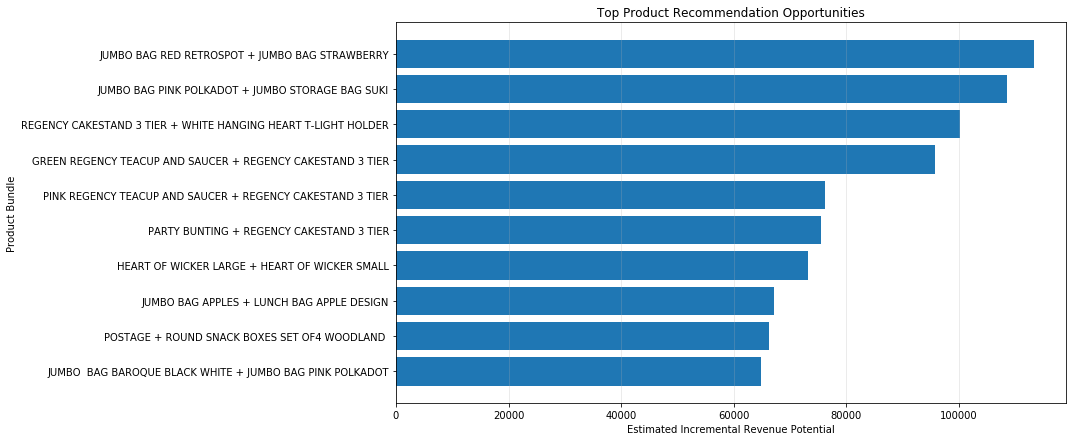

In [61]:
# Top product bundle opportunities

top_bundles = recommendation_bundle.head(10).copy()

top_bundles["Bundle"] = (
    top_bundles["Product_A"] + " + " +
    top_bundles["Recommendation_1"]
)

fig, ax = plt.subplots(figsize=(12,7))

ax.barh(
    top_bundles["Bundle"],
    top_bundles["Total_Incremental_Revenue_Potential"]
)

ax.set_title("Top Product Recommendation Opportunities")
ax.set_xlabel("Estimated Incremental Revenue Potential")
ax.set_ylabel("Product Bundle")

ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

fig.savefig(
    images_path / "top_product_recommendation_opportunities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()